<div dir="rtl" style="text-align: right; line-height: 1.9; font-family: 'Segoe UI', Tahoma, Arial, sans-serif; font-size: 16px;">

**[🡨 بازگشت به فصل سوم (توزیع‌های احتمال)](Fasl_3_Masterclass.ipynb)**

# 🎓 مسترکلاس مهندسی مالی تصادفی با پایتون
## فصل ۴: تولید اعداد تصادفی و شبیه‌سازی مونت‌کارلو (Monte Carlo Simulation & RNG)

---
### 🎯 هدف این نوت‌بوک
در فصول گذشته فهمیدیم که بازده‌های مالی چگونه توزیع می‌شوند. اما در دنیای واقعی، بسیاری از مشتقات مالی پیچیده (مانند آپشن‌های آسیایی یا سبدهای سرمایه‌گذاری) فرمول قیمت‌گذاری بسته (مثل بلک-شولز) ندارند.
ابزار نهایی ما در این شرایط، **شبیه‌سازی مونت‌کارلو (Monte Carlo Simulation)** است. ما هزاران مسیر احتمالی برای آینده تولید می‌کنیم و میانگین می‌گیریم. اما کامپیوترها ذاتاً «قطعی» (Deterministic) هستند. پس چگونه تصادف را شبیه‌سازی کنیم؟

در این فصل می‌آموزیم:
1. **روش تبدیل معکوس (Inverse Transform Method):** تولید هر توزیعی از توزیع یکنواخت.
2. **روش پذیرش-رد (Acceptance-Rejection Method):** نمونه‌برداری از توزیع‌های بسیار پیچیده با استفاده از توابع پوششی (Hat Functions).
3. **موتور مونت‌کارلو و کاهش واریانس (Variance Reduction):** استفاده از نمونه‌برداری اهمیتی (Importance Sampling) و متغیرهای متضاد (Antithetic Variates) برای افزایش دقت محاسبات.

</div>

In [ ]:
# Install necessary packages
!pip install scipy numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, expon, norm, beta, cosine
from scipy.optimize import minimize, shgo
from abc import ABC, abstractmethod
from typing import List
from dataclasses import dataclass

plt.style.use("seaborn-v0_8-darkgrid")
print("\n--- Setup Complete! Libraries for Monte Carlo Simulation are loaded. ---")


--- Setup Complete! Libraries for Monte Carlo Simulation are loaded. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۱: روش تبدیل معکوس (Inverse Transform Method)

کامپیوترها تنها می‌توانند اعداد شبه‌تصادفی از توزیع یکنواخت بین ۰ و ۱ ($U \sim Uniform(0,1)$) تولید کنند. اگر بخواهیم متغیر تصادفی $X$ با تابع توزیع تجمعی (CDF) برابر با $F(x)$ تولید کنیم، قضیه تبدیل معکوس می‌گوید:

$$ X = F^{-1}(U) $$

**مثال توزیع نمایی (Exponential):**
تابع CDF توزیع نمایی برابر است با $F(x) = 1 - e^{-\lambda x}$.
اگر قرار دهیم $U = 1 - e^{-\lambda x}$، آنگاه معکوس آن برابر خواهد بود با:
$$ x = \frac{-\ln(1-U)}{\lambda} $$

در بلوک زیر، این منطق ریاضی را در پایتون پیاده‌سازی کرده و خروجی آن را با توزیع استاندارد SciPy مقایسه می‌کنیم.

</div>

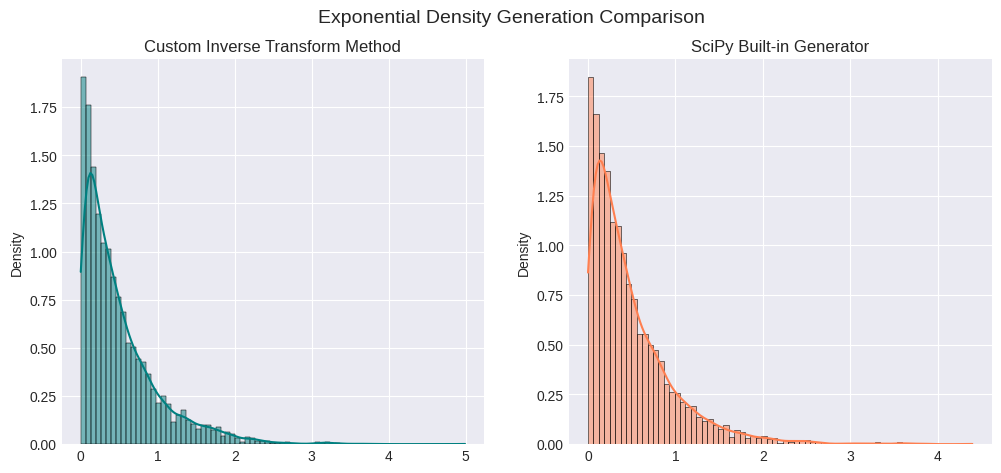

In [ ]:
# --- 1. Inverse Transform Method ---

def inverse_transform_method_rvs(F_inverse: callable, n_rv: int = 1000):
    """
    Generates random variables from any distribution using its inverse CDF.
    """
    # 1. Generate standard uniform random numbers U ~ (0,1)
    probs = uniform(0, 1).rvs(size=n_rv)

    # 2. Apply the inverse function: X = F^-1(U)
    return [F_inverse(p) for p in probs]

def test_inverse_transform():
    λ = 2.0

    # Mathematical Inverse CDF for Exponential Distribution: X = -ln(1-U) / λ
    def F_inverse_exponen(p):
        return -(np.log(1 - p)) / λ

    # Generate via our custom algorithm
    x_inv = inverse_transform_method_rvs(F_inverse_exponen, n_rv=5000)

    # Generate via SciPy built-in (for benchmark)
    x_scipy = expon.rvs(scale=1/λ, size=5000)

    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(x_inv, stat="density", kde=True, ax=ax[0], color="teal")
    ax[0].set_title("Custom Inverse Transform Method")

    sns.histplot(x_scipy, stat="density", kde=True, ax=ax[1], color="coral")
    ax[1].set_title("SciPy Built-in Generator")

    fig.suptitle("Exponential Density Generation Comparison", fontsize=14)
    plt.show()

test_inverse_transform()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۲: روش پذیرش-رد (Acceptance-Rejection Method)

بسیاری از توابع چگالی هدف ($f(x)$) معکوس‌پذیر نیستند. در این حالت از یک **توزیع پیشنهادی (Proposal Density - $g(x)$)** که نمونه‌برداری از آن آسان است استفاده می‌کنیم.
ما باید یک ثابت $C$ پیدا کنیم به طوری که تابع کلاه (Hat Function) $H(x) = C \cdot g(x)$ همواره بزرگتر از $f(x)$ باشد: $f(x) \le H(x)$.

**الگوریتم:**
1. یک نمونه $x$ از توزیع $g(x)$ تولید کن.
2. یک نمونه $U$ از $Uniform(0,1)$ تولید کن.
3. اگر $U \le \frac{f(x)}{H(x)}$ بود، $x$ را بپذیر (Accept). در غیر این صورت رد کن (Reject).

نویسنده کتاب یک معماری شی‌گرا بی‌نظیر برای پیدا کردن هوشمندانه ضریب $C$ و پارامتر بهینه $\theta$ با استفاده از الگوریتم بهینه‌سازی `scipy.optimize.minimize` ایجاد کرده است.

</div>

In [ ]:
# --- 2. Acceptance-Rejection Core Engine ---

class HatFunctionEstimator(ABC):
    @abstractmethod
    def estimate_parameters(self, f: callable, g: callable): ...

    @abstractmethod
    def H_x(self, x): ...

class SupremumEstimatorTemplate(HatFunctionEstimator, ABC):
    """
    Finds the optimal C and θ such that H(x) = C * g(x,θ) safely envelopes f(x).
    """
    def __init__(self):
        self._f, self._g = None, None
        self._C, self._θ = None, None

    @abstractmethod
    def _maximize_wrt_x(self, ratio_f: callable) -> tuple: ...

    @abstractmethod
    def _minimize_wrt_θ(self, ratio_f: callable) -> tuple: ...

    def _max_f_g_ratio(self, θ: tuple):
        def _c(x):
            proposal_prob = self._g(x, θ)
            return -(self._f(x) / proposal_prob) if proposal_prob > 0 else -1.0
        return self._maximize_wrt_x(_c)[0]

    def estimate_parameters(self, f: callable, g: callable):
        self._f, self._g = f, g
        # Min-Max optimization: Minimize the supremum of f/g w.r.t θ
        self._C, self._θ = self._minimize_wrt_θ(self._max_f_g_ratio)
        print(f">>> Hat Function Parameter found: C = {self._C:.4f}, Optimal θ = {self._θ}")

    def H_x(self, x):
        return self._C * self._g(x, self._θ)

    @property
    def θ_optimal_for_g(self): return self._θ

class DefaultSupremumEstimator(SupremumEstimatorTemplate):
    def __init__(self, x0: List, x0_bounds: List[tuple], θ0: List, θ0_bounds: List[tuple]):
        self._x0, self._x0_bounds = x0, x0_bounds
        self._θ0, self._θ0_bounds = θ0, θ0_bounds
        super().__init__()

    def _maximize_wrt_x(self, ratio_f: callable) -> tuple:
        res = minimize(ratio_f, x0=self._x0, bounds=self._x0_bounds)
        return -res.fun, res.x

    def _minimize_wrt_θ(self, ratio_f: callable) -> tuple:
        res = minimize(ratio_f, x0=self._θ0, bounds=self._θ0_bounds)
        return res.fun, res.x

class SamplesTraceDisplay:
    def __init__(self, accepted, rejected, accepted_prob, rejected_prob):
        self.acc, self.rej = accepted, rejected
        self.p_acc, self.p_rej = accepted_prob, rejected_prob

    def plot(self):
        df_acc = pd.DataFrame({"Sample": self.acc, "Probability": self.p_acc, "Type": "Accepted (f(x))"})
        df_rej = pd.DataFrame({"Sample": self.rej, "Probability": self.p_rej, "Type": "Rejected (H(x))"})

        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=pd.concat([df_acc, df_rej]), x="Sample", y="Probability", hue="Type", style="Type", alpha=0.6)
        plt.title("Acceptance-Rejection Sampling Trace")
        plt.show()

class AcceptanceRejectionMethod(ABC):
    def __init__(self, hat_func_estimator: HatFunctionEstimator):
        self._hat_func_estimator = hat_func_estimator

    @abstractmethod
    def target_pdf_f(self, x): ...
    @abstractmethod
    def _proposal_pdf_g(self, x, θ: tuple): ...
    @abstractmethod
    def _sample_from_proposal_g_with_θ_optimal(self, n_rv): ...

    def sample(self, n_rv):
        self._hat_func_estimator.estimate_parameters(f=self.target_pdf_f, g=self._proposal_pdf_g)
        rv_f_accepted, rv_f_rejected = [], []

        while len(rv_f_accepted) < n_rv:
            remaining = n_rv - len(rv_f_accepted)
            rv_g = self._sample_from_proposal_g_with_θ_optimal(remaining)
            u = uniform.rvs(0, 1, remaining)

            # Core Acceptance Logic: U <= f(x) / H(x)
            for x_val, u_val in zip(rv_g, u):
                if u_val <= self.target_pdf_f(x_val) / self._hat_func_estimator.H_x(x_val):
                    rv_f_accepted.append(x_val)
                else:
                    rv_f_rejected.append(x_val)
                if len(rv_f_accepted) == n_rv: break

        trace = SamplesTraceDisplay(rv_f_accepted, rv_f_rejected,
                                    self.target_pdf_f(rv_f_accepted),
                                    self._hat_func_estimator.H_x(rv_f_rejected))
        return rv_f_accepted, trace

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### اجرای روش پذیرش-رد (تولید توزیع گوسی از نمایی)
در این بخش می‌خواهیم یک توزیع هدف نرمال (Gaussian) را تولید کنیم، اما تنها توزیع پیشنهادی که در اختیار داریم توزیع نمایی (Exponential) است. الگوریتم هوشمند بالا، مرز پوشاننده (Hat Function) را یافته و نمونه‌های معتبر را جدا می‌کند.

</div>

Generating Gaussian Samples using Exponential Proposal...
>>> Hat Function Parameter found: C = 2.9070, Optimal θ = [0.17539052]


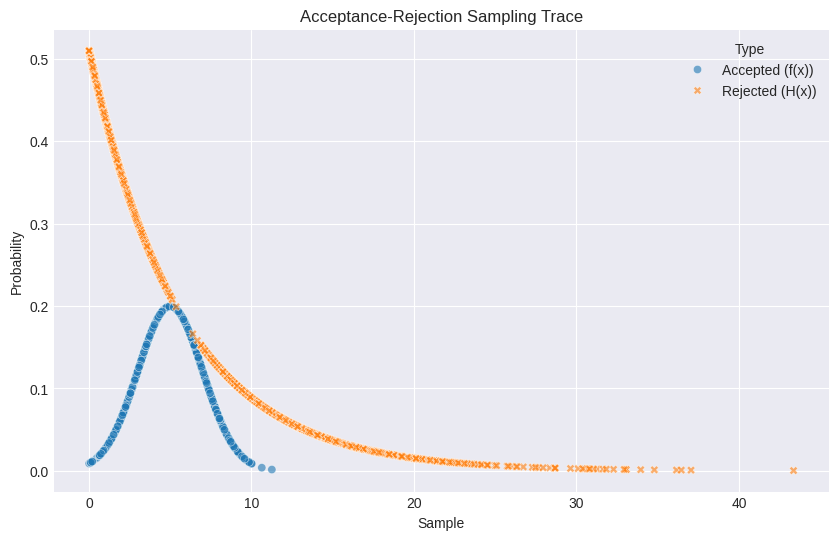

In [ ]:
class GaussianVariateGeneratorWithExponential(AcceptanceRejectionMethod):
    """
    Target: Gaussian f(x)
    Proposal: Exponential g(x)
    """
    def __init__(self, μ, σ, hat_func_optimizer: HatFunctionEstimator):
        self._μ, self._σ = μ, σ
        super().__init__(hat_func_optimizer)

    def target_pdf_f(self, x): return norm.pdf(x, loc=self._μ, scale=self._σ)
    def _proposal_pdf_g(self, x, θ: tuple): return expon.pdf(x, scale=1 / θ[0])
    def _sample_from_proposal_g_with_θ_optimal(self, n_rv):
        return expon.rvs(scale=1 / self._hat_func_estimator.θ_optimal_for_g[0], size=n_rv)

# Run the simulation
print("Generating Gaussian Samples using Exponential Proposal...")
estimator = DefaultSupremumEstimator(x0=[0.01], x0_bounds=[(0.01, None)],
                                     θ0=[0.01], θ0_bounds=[(0.001, None)])
gen = GaussianVariateGeneratorWithExponential(μ=5, σ=2, hat_func_optimizer=estimator)
samples, trace = gen.sample(n_rv=1000)
trace.plot()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۳: معماری شبیه‌سازی مونت‌کارلو و کاهش واریانس

طبق قانون اعداد بزرگ (Law of Large Numbers)، امید ریاضی یک تابع دلخواه $H(x)$ برابر است با میانگین نمونه‌ای آن در بی‌نهایت شبیه‌سازی:
$$ \mathbb{E}[H(X)] \approx \frac{1}{N} \sum_{i=1}^N H(x_i) $$

اما در دنیای واقعی، تولید $N$ بزرگ به معنای هزینه سنگین پردازشی است. برای افزایش دقت بدون افزایش $N$، ما از **تکنیک‌های کاهش واریانس (Variance Reduction)** استفاده می‌کنیم:

۱. **نمونه‌برداری متضاد (Antithetic Variates):** اگر مسیر تصادفی $x$ را تولید کردیم، مسیر قرینه $-x$ را نیز استفاده می‌کنیم. این کار کوواریانس منفی ایجاد کرده و واریانس کل را کم می‌کند:
$$ H_{anti} = \frac{H(x) + H(-x)}{2} $$

۲. **نمونه‌برداری اهمیتی (Importance Sampling):** به جای توزیع اصلی $f(x)$، از توزیع دیگری مثل $g(x)$ (که رخدادهای نادر را بیشتر شبیه‌سازی می‌کند) نمونه می‌گیریم و سپس نتیجه را با نسبت درست‌نمایی اصلاح می‌کنیم:
$$ \mathbb{E}_f[H(X)] = \mathbb{E}_g\left[ H(X) \frac{f(X)}{g(X)} \right] $$

</div>

In [ ]:
# --- 3. Monte Carlo & Variance Reduction Engine ---

def _compute_standard_error(H_x, mean, axis, n):
    H_x_2 = np.power(H_x, 2)
    return (np.sum(H_x_2, axis=axis) - (n * (mean ** 2))) / (n * (n - 1))

class TargetSamplingDensity(ABC):
    @abstractmethod
    def pdf(self, x): ...
    @abstractmethod
    def sample(self, n_vars, n_sample_paths=1): ...

class StandardNormalTargetSamplingDensity(TargetSamplingDensity):
    def pdf(self, x): return norm.pdf(x)
    def sample(self, n_vars, n_sample_paths=1): return norm().rvs(size=(n_sample_paths, n_vars))

# --- Variance Reduction Schemes ---
class VarReduction(ABC):
    def __init__(self):
        self._axis = 0
        self._n = 0
        self._h_x_fun = None
        self._n_vars = 0
        self._n_sample_paths = 1
    @abstractmethod
    def sample_H_x(self, x=None): ...

class NoVarReduction(VarReduction):
    def sample_H_x(self, x=None):
        print('Applying Standard Monte Carlo (No Variance Reduction)')
        H_x = np.vectorize(lambda y: self._h_x_fun(y), otypes=[float])
        return H_x(x)

class AntitheticSampling(VarReduction):
    def sample_H_x(self, x=None):
        print('Applying Antithetic Sampling (Variance Reduction)')
        H_x = np.vectorize(lambda y: (self._h_x_fun(y) + self._h_x_fun(-y)) / 2, otypes=[float])
        return H_x(x)

class ImportanceSampling(VarReduction, ABC):
    def __init__(self):
        self._target_sampling_density = None
        super().__init__()
    @abstractmethod
    def _proposal_g_x(self, x, θ: tuple): ...
    @abstractmethod
    def _sample_from_proposal_density_g(self, θ: tuple): ...

    def sample_H_x(self, x=None):
        print('Applying Importance Sampling (Optimizing Proposal Density...)')
        def _likelihood_ratio(x_val, θ):
            return self._target_sampling_density.pdf(x_val) / self._proposal_g_x(x_val, θ)

        def _H_x_with_θ(θ):
            x_new = self._sample_from_proposal_density_g(θ)
            H_x = np.vectorize(lambda y: self._h_x_fun(y) * _likelihood_ratio(y, θ), otypes=[float])
            return H_x(x_new)

        def _compute_total_variance(θ: tuple):
            H_x_vals = _H_x_with_θ(θ)
            mean = np.average(H_x_vals, axis=self._axis)
            return np.sum(_compute_standard_error(H_x=H_x_vals, mean=mean, axis=self._axis, n=self._n))

        # Global Optimization using SHGO (Simplicial Homology Global Optimization)
        optimal_θ = shgo(_compute_total_variance, bounds=[(-2, 2), (0.1, 2)]).x
        print(f'Optimal θ found: {optimal_θ}')
        return _H_x_with_θ(optimal_θ)

class GaussianImportanceSampling(ImportanceSampling):
    def _proposal_g_x(self, x, θ: tuple): return norm.pdf(x, loc=θ[0], scale=θ[1])
    def _sample_from_proposal_density_g(self, θ: tuple):
        return norm.rvs(size=(self._n_sample_paths, self._n_vars), loc=θ[0], scale=θ[1])

class MonteCarloSimulation:
    @dataclass
    class MCEstimate:
        samples: List = None
        mean: float = 0.0
        standard_error: float = 0.0

    def __init__(self, h_x_fun: callable, target_sampling_density: TargetSamplingDensity,
                 n_vars: int, n_sample_paths: int=1, var_reduction: VarReduction = NoVarReduction()):
        self._h_x_fun = h_x_fun
        self._n_vars, self._n_sample_paths = n_vars, n_sample_paths
        self._axis, self._n = (0, self._n_sample_paths) if self._n_sample_paths > 1 else (1, self._n_vars)
        self._target_sampling_desnity = target_sampling_density
        self._var_reduction = var_reduction

        # Inject dependencies into VarReduction strategy
        self._var_reduction._target_sampling_density = target_sampling_density
        self._var_reduction._n_sample_paths = n_sample_paths
        self._var_reduction._n_vars = n_vars
        self._var_reduction._h_x_fun = h_x_fun
        self._var_reduction._axis = self._axis
        self._var_reduction._n = self._n

    def new_estimate(self):
        x = self._target_sampling_desnity.sample(n_vars=self._n_vars, n_sample_paths=self._n_sample_paths)
        estimate = self.MCEstimate()
        estimate.samples = self._var_reduction.sample_H_x(x)
        estimate.mean = np.average(estimate.samples, axis=self._axis)
        estimate.standard_error = np.sqrt(_compute_standard_error(estimate.samples, estimate.mean, self._axis, self._n))
        return estimate

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### اجرای عملی: مقایسه روش استاندارد با روش کاهش واریانس
در بلاک زیر، ما قصد داریم انتگرال (امید ریاضی) تابع $H(x) = e^{-x}$ را تحت توزیع نرمال محاسبه کنیم.
نخست از مونت‌کارلوی کلاسیک استفاده کرده و سپس روش هوشمندانه **Importance Sampling** را فراخوانی می‌کنیم که به طور اتوماتیک واریانس و خطای استاندارد (Standard Error) را کاهش می‌دهد.

</div>

In [ ]:
def test_monte_carlo_comparisons():
    print("--- Test 1: Standard Monte Carlo ---")
    mcs_standard = MonteCarloSimulation(h_x_fun=lambda x: np.exp(-x),
                                        n_vars=4, n_sample_paths=500,
                                        target_sampling_density=StandardNormalTargetSamplingDensity())
    est_std = mcs_standard.new_estimate()
    print(f"Expected Value (Mean): {est_std.mean[0]:.6f}")
    print(f"Standard Error: {est_std.standard_error[0]:.6f}\n")

    print("--- Test 2: Monte Carlo with Importance Sampling ---")
    mcs_importance = MonteCarloSimulation(h_x_fun=lambda x: np.exp(-x),
                                          n_vars=4, n_sample_paths=500,
                                          var_reduction=GaussianImportanceSampling(),
                                          target_sampling_density=StandardNormalTargetSamplingDensity())
    est_imp = mcs_importance.new_estimate()
    print(f"Expected Value (Mean): {est_imp.mean[0]:.6f}")
    print(f"Standard Error: {est_imp.standard_error[0]:.6f}")

test_monte_carlo_comparisons()

--- Test 1: Standard Monte Carlo ---
Applying Standard Monte Carlo (No Variance Reduction)
Expected Value (Mean): 1.631543
Standard Error: 0.096864

--- Test 2: Monte Carlo with Importance Sampling ---
Applying Importance Sampling (Optimizing Proposal Density...)
Optimal θ found: [1.99560519 0.10298012]
Expected Value (Mean): 0.007379
Standard Error: 0.001441


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

---
### 🏁 نتیجه‌گیری فصل ۴
در این فصل قدرتمندترین الگوریتم‌های شبیه‌سازی مالی را به صورت شی‌گرا پیاده کردیم. مشاهده کردید که چگونه با استفاده از **کاهش واریانس**، توانستیم خطای محاسبات (Standard Error) را بدون افزایش تعداد مسیرهای شبیه‌سازی کاهش دهیم. این مفاهیم پایه و اساس قیمت‌گذاری مشتقات پیچیده در بازارهای مالی و همچنین پایه‌ای برای **یادگیری تقویتی (Reinforcement Learning)** در هوش مصنوعی مالی هستند.

در فصل بعد (فصل ۵)، وارد دنیای «فرآیندهای تصادفی پیوسته» و معادلات دیفرانسیل تصادفی (مانند حرکت براونی) خواهیم شد.

</div>